# Chapter 5: Pandas

While NumPy is the foundation of much of the SciPy ecosystem and provides very capable ndarray objects, it has a few missing features.

- The ability to have arrays with multiple parameters i.e. strings, integers, floats ect... It will convert all items in the array to strings to make it compatible
- Data labelling, does not allow for the labelling of columns or rows, grouping data based on the value of a particular column or the ability to merge two datasets with automatic alignment of related data.

To fill in these missing features, the pandas library provides a wealth of additional tools on top of NumPy for working with data, and possibly the most endearing feature, the ability to call data based on labels. That is, data columns and rows can contain human-readable labels that are used to access the data. Pandas still supports accessing data using indices if the user wishes to go that route, but the user can now access data without knowing which column it is in as long as the user knows the column label.



In [51]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

os.chdir(os.path.dirname(os.path.abspath(__vsc_ipynb_file__)))

## 5.1 Basic Panda Objects

Pandas uses its own objects to hold data called a `Series` and a `DataFrame`, which are built on NumPy arrays. Because they are built on NumPy, many of the NumPy functions (e.g., `np.mean()`) work on pandas objects. 

The key difference between a `Series` and `DataFrame` is that a Series is one-dimensional while a DataFrame is two-dimensional. Unlike a NumPy array, pandas objects have fixed dimensionality. 
>There is a three-dimensional object called a Panel, but this will not be covered here as it is not often used.

### 5.1.1 Series
While the pandas Series is restricted to being a single dimension, it can be as long as necessary to hold the data. A Series containing the atomic masses of the first five elements on the periodic table is generated below using the `pd.Series()` function. 
>This function is always capitalised.

The right column is the actual data in the Series, while the values on the left are the assigned indices for each value in the Series. The index column is not part of the dimensionality of the Series it is *metadata* (i.e., data about the data). Think of the numbers as the row labels you would see in a traditional spreadsheet software application.


In [52]:
mass = pd.Series([1.01, 4.00, 6.94, 9.01, 10.81])
mass

0     1.01
1     4.00
2     6.94
3     9.01
4    10.81
dtype: float64

Consistent with lists, tuples, and ndarrays, values in a Series can be accessed using indexing with square brackets as demonstrated below.

In [53]:
mass[2]

np.float64(6.94)

Unlike most other multi-element objects seen so far, data in a Series can be accessed using indices different from the default (i.e., 0, 1, 2, etc.) values. That is, custom row labels can be assigned using the `index=` argument shown below.

The custom indices can now be used to access an element in a Series. This makes a Series behave something like a dictionary

In [54]:
index=('H', 'He', 'Li', 'Be', 'B')
mass2 = pd.Series([1.01, 4.00, 6.94, 9.01, 10.81], index=index)
mass2

H      1.01
He     4.00
Li     6.94
Be     9.01
B     10.81
dtype: float64

In [55]:
mass2['He']

np.float64(4.0)

The indices can be accessed by using `mass2.index`. Series indices can also be modified after a Series has been created by using `.index` and assignment as demonstrated below.

In [56]:
mass2.index

Index(['H', 'He', 'Li', 'Be', 'B'], dtype='str')

In [57]:
mass.index =['H', 'He', 'Li', 'Be', 'B']
mass

H      1.01
He     4.00
Li     6.94
Be     9.01
B     10.81
dtype: float64

Even if we create or modify a Series to have custom indices, we can still access the elements using the traditional numerical indices using the `iloc[]` method. This method allows the user to access elements the same way as in a NumPy array regardless of custom index values.

In [58]:
mass2.iloc[2]
#mass2[2] would give an error, as no index '2' exists

np.float64(6.94)

### 5.1.2 DataFrame
Most data you will find yourself working with will be best placed in a two-dimensional pandas object called a **DataFrame**, which is always written with two capital letters. The **DataFrame** is similar to a Series except that now there are also columns with names. The columns can be accessed by column names, and rows can be accessed by indices. You might think of a **DataFrame** as a collection of Series objects. 

Below, a **DataFrame** is constructed to hold the names, atomic numbers, masses, and ionization energies of the first five elements.

In [59]:
name = ['hydrogen', 'helium', 'lithium', 'beryllium','boron']
AN = [1, 2, 3, 4, 5]
mass = [1.01, 4.00, 6.94, 9.01, 10.81]
IE = [13.6, 24.6, 5.4, 9.3, 8.3]

In [114]:
columns = ['H', 'He', 'Li', 'Be','B'] 
index = ['name', 'AN', 'mass', 'IE']
elements = pd.DataFrame([name, AN, mass, IE], 
                        columns=columns, index=index)
elements

,H,He,Li,Be,B
name,hydrogen,helium,lithium,beryllium,boron
AN,1,2,3,4,5
mass,1.01,4.0,6.94,9.01,10.81
IE,13.6,24.6,5.4,9.3,8.3


To access data in a DataFrame, place the column name in square brackets.

In [61]:
elements['Be']

name    beryllium
AN              4
mass         9.01
IE            9.3
Name: Be, dtype: object

Essentially, what we get out of a column is a Series with the indices shown on the leftward side.

To indicate a row, instead use the `loc[]` method. We again get a Series with indices derived from the column names in the source DataFrame. This Series can be placed in a variable and indexed just like in section 5.1.1.

In [62]:
elements.loc['IE']

H     13.6
He    24.6
Li     5.4
Be     9.3
B      8.3
Name: IE, dtype: object

In [63]:
atomic_number = elements.loc['AN']
atomic_number['B']

5

Alternatively, we can use the DataFrame directly and index it with the `loc[]` method as `[row, column]`.


In [64]:
elements.loc['IE','Li']

5.4

Numerical index values can also be used with the `iloc[]` method. This reduces indexing to how NumPy arrays are indexed.

In [65]:
elements.iloc[2:, 2]

mass    6.94
IE       5.4
Name: Li, dtype: object

### Table 1 - A summary of methods indexing panda series and data frames.
| Index Method            | Description                                      |
|-------------------|--------------------------------------------------|
| `s[index]` | Index Series with assigned index values               |
| `s.iloc[index]`  | Index series with default numerical index values               |
| `df[column]`  | Index DataFrame with column name       |
| `df.loc[row]`  | Index DataFrame with row name     |
| `df.loc[row, column]`  | Index DataFrame with row and column names     |
| `df.iloc[row, column]`  | Index DataFrame with row and column default numerical index values      |

## 5.2 Reading/Writing Data
Similar to NumPy, pandas contains functions for reading and writing data to and from its own object types, with each function suited to a specific file format.

Table 2 - Import/Export Functions in pandas
|Function|Description|
|--------|-----------|
|`read_csv()`and`to_csv()`|Imports/Exports data from/to a CSV file|
|`read_table()`and`to_table()`|General-purpose importer/exporter|
|`read_hdf5()`and`to_hdf5()`|Imports/Exports data from/to an HDF5 file|
|`read_clipboard()`and`to_clipboard()`|Transfers data to/from clipboard to Series or DataFrame|
|`read_excel()`and`to_excel()`|Reads/Writes an Excel file|

### 5.3.1 General-Purpose delimited File Reader
Pandas provides a general-purpose file reader `pd.read_table()`, this function imports text files where lines represent rows, and the data in each row is separated by charcters or spaces. The user can designate what character(s) separate the data by using the `delimiter` or `sep` arguments.

|Argument|Description|
|--------|-----------|
|`delimiter`|Data seperator; default is tab|
|`sep`|Data separator; default is tab|
|`skiprows`|Number of tows at the top of file to skip before reading data|
|`skipfooter`|Number of rows at the bottom of file to skip|
|`skip_blank_lines`|If `true`, skips blank lines in files; default is `false`|
|`header`|Row number o use for a header; also accepts None if no header is provided in the file|
|`skipinitialspace`|If `True`, skips white space after delimiter|

As an example, we can use this function to read a calculated PDB file of benzene and extract the $xyz$ coordinates for each atom. This particular file type, shown below, is strictly formatted based on the position in a line, but being that all the data columns here have spaces between them, we can use space delimitation by setting `sep=\s+`. Because the data do not start until the third line and we do not need the last thirteen lines of the file, we should exclude these rows. We set `header=None` because we do not want the function to treat the first line of data as a header or data label.

The $x$,$y$ and $z$ data are in columns 5,6 and 7 respectively, and can be extracted by indexing

In [66]:
benz = pd.read_table('data/benzene.pdb', 
                     sep=r'\s+', skiprows=2, skipfooter=13, header=None, 
                     engine='python')
benz

,0,1,2,3,4,5,6,7
0,HETATM,1,H,UNK,1,0.0,0.000,-0.020
1,HETATM,2,C,UNK,1,0.0,0.000,1.067
2,HETATM,3,C,UNK,1,0.0,0.000,3.857
3,HETATM,4,C,UNK,1,0.0,-1.208,1.764
4,HETATM,5,C,UNK,1,0.0,1.208,1.764
5,HETATM,6,C,UNK,1,0.0,1.208,3.159
6,HETATM,7,C,UNK,1,0.0,-1.208,3.159
7,HETATM,8,H,UNK,1,0.0,-2.149,1.221
8,HETATM,9,H,UNK,1,0.0,2.149,1.221
9,HETATM,10,H,UNK,1,0.0,2.149,3.703


### 5.2.2 Comma Separated Values Files
Pandas provides a collection of more format-specific functions for reading/writing files. The most popular is possibly the CSV file because it is simple, and many scientific instruments support exporting data in this format. To import a CSV file, we will use the `read_csv()` function. This function is very similar to the `read_table()` function except that a default value for the separator/delimiter is set to a comma. To create a CSV file, use the `to_csv()` method, which at a minimum requires the file name and a pandas object with the data.

We can write the above chemical element data assembled in section 5.1 as shown below. Because we are starting from a pandas object and are using a pandas method, the `df.to_csv()` format is used where df is a DataFrame.

In [67]:
elements.to_csv('data/elements.csv')

If we check the directory containing the Jupyter notebook, the data folder contains a file titled elements.csv that looks like the following. Each row in the DataFrame is a different line in the file, and every column is separated by a comma.

To read the data back in from the file, use `pd.read_csv()`. Because we are not starting with a pandas object, the function is called using the `pd.function()` format.

In [68]:
pd.read_csv('data/elements.csv')

,Unnamed: 0,H,He,Li,Be,B
0,name,hydrogen,helium,lithium,beryllium,boron
1,AN,1,2,3,4,5
2,mass,1.01,4.0,6.94,9.01,10.81
3,IE,13.6,24.6,5.4,9.3,8.3


### 5.2.3 Excel Notebook Files
Pandas provides another useful function that imports Excel notebook files (i.e., .xls or .xlsx). Excel files are a specialized file type that requires the support of additional libraries, known as dependencies, that pandas does not install by default. A list of these dependencies is provided on the pandas website. You can either install each dependency yourself, or pandas provides a shortcut (for pandas version 2.0.0 and later) of `pip install "pandas[excel]"` that is run in the Terminal window. However, please check the pandas website for the full and most current instructions as things may have changed. Because Excel files can contain multiple sheets, this function is a little more complicated to use. The simplest way to import an Excel file is to use `pd.read_excel()` and provide it with the Excel file name.

Pandas loads the first sheet in the file by default. If you want to access a different sheet in the file, you can specify this by using the `sheet_name` keyword argument. If you do not know the sheet name, the `sheet_name` argument also accepts integer index values (i.e., 0 for the first sheet and so on).

### 5.2.4 Computer Clipboard
Pandas will also accept data from the computer’s copy and paste clipboard. Start by highlighting some data from a webpage or a spreadsheet, then select copy. This is typically located under the Edit menu of most software applications. Alternatively, you can type Command + C on a macOS or Control + C on Windows and Linux. Finally, use the `pd.read_clipboard()` function to convert it to a pandas DataFrame.

```python
pd.read_clipboard()
```

Loading data from the clipboard is not a robust and efficient way to do much of your automated data analysis, but it is a very convenient method to experiment with data or to quickly grab some data off a website to experiment with.



## 5.3 Examining Data with Pandas
Once you load data into pandas, you will likely want to get an idea of what the data look like before you proceed to calculations and in-depth analyses. This section covers a few methods provided in pandas to gain a preliminary understanding of your data.

### 5.3.1 Descriptive Functions
Pandas provides a few simple functions to view and describe new data. The first two are `head()` and `tail()` which allow you to see the top and bottom of the DataFrame, respectively. These are particularly useful when dealing with very large DataFrames. 

Below, a DataFrame containing random values in an even, normal, and Poisson distribution ($\lambda$ = 3.0) demonstrates these functions.

In [69]:
rng = np.random.default_rng()

random = pd.DataFrame({'even': rng.random(1000),
                       'normal': rng.normal(size=1000),
                       'poisson': rng.poisson(lam=3.0, size=1000)})

In [70]:
random.head()

,even,normal,poisson
0,0.667356,-0.566080,5
1,0.578937,2.744130,4
2,0.026101,-0.049476,5
3,0.064229,0.073903,2
4,0.252344,2.006634,2


In [71]:
random.tail()

,even,normal,poisson
995,0.652721,0.132555,6
996,0.974466,0.472456,3
997,0.998511,-0.110443,1
998,0.370537,0.019839,1
999,0.869988,2.286453,3


Pandas also contains a `describe()` function which returns a variety of statistics on each column. For example, the means are provided, which are approx 0.5, 0.0 and 3.0 for the even, normal and poisson distributions.

In [73]:
random.describe()

,even,normal,poisson
count,1000.000000,1000.000000,1000.000000
mean,0.500144,-0.039196,3.030000
std,0.291802,0.976255,1.675681
min,0.001883,-3.002724,0.000000
25%,0.234987,-0.679401,2.000000
50%,0.493737,-0.048207,3.000000
75%,0.760296,0.560891,4.000000
max,0.999056,3.186430,9.000000


Another useful function is the `value_counts()` method, which returns all unique values in a Series, DataFrame column or row. Bellow is an example on the poisson column, being that the other two columns will have a relatively large number of unique values

In [74]:
counts = random['poisson'].value_counts()
counts

poisson
2    223
3    212
4    179
1    154
5    118
6     47
0     39
7     20
8      6
9      2
Name: count, dtype: int64

Data in DataFrames can be plotted by calling the desired columns of data and feeding them into plotting functions like `plt.scatter()`. The data can also be visualised by using the `df.plot(kind=)` format where `df` is the DataFrame and `kind` is the plot type (e.g. `bar`, `hist`, `scatter`, `line`, `pie`, etc.)

However matplotlib doing the plotting and is largely redundant with other methods

<Axes: xlabel='poisson'>

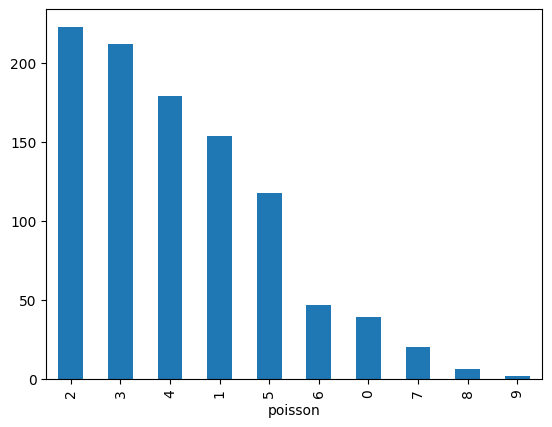

In [75]:
counts.plot(kind='bar')

### 5.3.2 Broadcasted Mathematical Operations
Because pandas is built upon NumPy arrays, mathematical operations are propagated through Series and DataFrames. The user is able to use NumPy methods on pandas objects, and there are a number of other mathematical operations to choose from such as those listed below.

Table 4 - Broadcasted Pandas Methods
|Function|Description|
|--------|-----------|
|`abs()`|Absolute value|
|`count()`|Counts items|
|`cumsum()`|Cumulative Sum|
|`cumprod()`|Cumulative Product|
|`max()`|Maximum|
|`min()`|Minimum|
|`mean()`|Mean|
|`median()`|Median|
|`mode()`|Mode|
|`std()`|Standard Deviation|

### 5.4.1 Insert Columns via Assignment
Possibly the easiest method of adding a new column is through assignment. If a nonexistent column is called and assigned values, instead of returning an error, pandas creates a new column with the given name and populates it with the data. For example, the `elements` DataFrame below does not contain a carbon column, so the column is added when assigned to a Series with the data.



In [76]:
elements

,H,He,Li,Be,B
name,hydrogen,helium,lithium,beryllium,boron
AN,1,2,3,4,5
mass,1.01,4.0,6.94,9.01,10.81
IE,13.6,24.6,5.4,9.3,8.3


In [77]:
elements['C'] = ['carbon', 6, 12.01, 11.3]
elements

,H,He,Li,Be,B,C
name,hydrogen,helium,lithium,beryllium,boron,carbon
AN,1,2,3,4,5,6
mass,1.01,4.0,6.94,9.01,10.81,12.01
IE,13.6,24.6,5.4,9.3,8.3,11.3


### 5.4.2 Automatic Alignment
Another important feature of pandas is the ability to automatically align data based on labels. In the above example, carbon is added to the DataFrame with the name, atomic number, atomic mass, and ionization energy in the same order as in the DataFrame. What happens if the new data is not in the correct order? If we are using NumPy, this would require additional effort on the part of the user to reorder the data. However, if each value is labeled, pandas will see to it that they are placed in the correct location.

In [84]:
nitrogen = pd.Series([7, 14.01, 'nitrogen', 14.5], 
                     index=['AN', 'mass', 'name', 'IE'])
nitrogen

AN             7
mass       14.01
name    nitrogen
IE          14.5
dtype: object

Data for nitrogen is placed in a Series above. Notice that the values are out of order with respect to the data in `elements`. There are index labels (i.e., row labels) that tell pandas what each piece of data is, and pandas will use them to determine where to place the new information.

The new column of nitrogen data has been added to `elements` with all pieces of data residing in the correct row.

In [85]:
elements['N'] = nitrogen
elements

,H,He,Li,Be,B,C,N
name,hydrogen,helium,lithium,beryllium,boron,carbon,nitrogen
AN,1,2,3,4,5,6,7
mass,1.01,4.0,6.94,9.01,10.81,12.01,14.01
IE,13.6,24.6,5.4,9.3,8.3,11.3,14.5


### 5.4.3 Dropping Columns

When cleaning up data, you may wish to exclude or drop a column and/or row. Pandas provides the `drop()` method for this purpose. It requires the name of the column or tow to be dropped, by default it assumes a row, `axis=0`, is to be dropped.

If you want to drop a column, change the axis using `axis=1` argument.

In [92]:
elements.drop('C', axis=1)

,H,He,Li,Be,B,N
name,hydrogen,helium,lithium,beryllium,boron,nitrogen
AN,1,2,3,4,5,7
mass,1.01,4.0,6.94,9.01,10.81,14.01
IE,13.6,24.6,5.4,9.3,8.3,14.5


In [ ]:
#since axis by deafult is 0 this can be done without axis being defined, but it is good practice to be explicit about the axis being dropped
elements.drop('IE', axis=0)

,H,He,Li,Be,B,C,N
name,hydrogen,helium,lithium,beryllium,boron,carbon,nitrogen
AN,1,2,3,4,5,6,7
mass,1.01,4.0,6.94,9.01,10.81,12.01,14.01


By default the `drop()` function does not modify the original DataFrame shown by the Carbon column being present after being dropped. To make changes permanent, either assign the newly created DataFrame to a variable or add the `inplace=True` keyword argument to the function

There is a similar function `pd.dropna()` which drops columns or rows from a DataFrame which excludes the `nan` values. This is commonly used to remove incomplete data from a dataset. 

The `pd.dropna()` function behaves very similar to `pd.drop()` including the `inplace=` and `axis=` arguments

### 5.4.4 Merge
To merge multiple DataFrames, pandas provides a `merge()` method. Similar to above, the `merge()` function will properly align data, but because DataFrames have multiple columns and index values to choose from, the `merge()` function can align data based on any of these values. The default behaviour for `merge()` is to check for common columns between the two DataFrames and align the data based on those columns. As an example, below are two DataFrames containing data from various chemical compounds.

In [93]:
chemdata1 = [['MW', 58.08, 32.04], ['dipole', 2.91, 1.69], 
             ['formula', 'C3H6O', 'CH3OH']] 
columns=['property','acetone', 'methanol']
chmdf1 = pd.DataFrame(chemdata1, columns=columns)

chmdf1

,property,acetone,methanol
0,MW,58.08,32.04
1,dipole,2.91,1.69
2,formula,C3H6O,CH3OH


In [94]:
chmdata2 = [['formula', 'C6H6', 'H2O'], ['dipole', 0.00, 1.85], 
            ['MW', 78.11, 18.02]]
chmdf2 = pd.DataFrame(chmdata2 , columns=['property', 'benzene', 'water'])

chmdf2

,property,benzene,water
0,formula,C6H6,H2O
1,dipole,0.0,1.85
2,MW,78.11,18.02


Both DataFrames above have a property column, so the `merge()` function uses this common column to align all the data into a new DataFrame.

In [95]:
chmdf1.merge(chmdf2)

,property,acetone,methanol,benzene,water
0,MW,58.08,32.04,78.11,18.02
1,dipole,2.91,1.69,0.0,1.85
2,formula,C3H6O,CH3OH,C6H6,H2O


If there are multiple columns with the same name, the user can specify which to use with the on keyword argument (e.g., `on='property'`). Alternatively, if the two DataFrames contain columns with different names that the user wants used for alignment, the user can specify which columns to use with the `left_on` and `right_on` keyword arguments.

In [96]:
comps1 = pd.DataFrame({'element':['Co', 'Fe', 'Cr','Ni'], 
                       'protons': [27, 26, 24, 28]})
comps2 = pd.DataFrame({'metal':['Fe', 'Co', 'Cr', 'Ni'], 
                       'IE': [7.90, 7.88, 6.79, 7.64]})

In [99]:
comps1.merge(comps2, left_on='element',right_on='metal')

,element,protons,metal,IE
0,Co,27,Co,7.88
1,Fe,26,Fe,7.90
2,Cr,24,Cr,6.79
3,Ni,28,Ni,7.64


In [106]:
comps3 = comps1.merge(comps2, left_on='element', 
                      right_on='metal')
comps3.drop('metal', axis=1, inplace=True)
comps3

,element,protons,IE
0,Co,27,7.88
1,Fe,26,7.90
2,Cr,24,6.79
3,Ni,28,7.64


### 5.4.5 Concatenation
Concatenation is the process of splicing two DataFrames along a given axis. This is different from the `merge()` method above in that `merge()` merges and aligns common data between the two DataFrames while p`d.concat()` blindly appends one DataFrame to another. 

As an example, imagine two lab groups measure the densities of magnesium, aluminum, titanium, and iron and load their results into DataFrames below.

In [107]:
group1 = pd.DataFrame({'metal':['Mg', 'Al', 'Ti', 'Fe'], 
                       'density': [1.77, 2.73, 4.55, 7.88]})
group2 = pd.DataFrame({'metal':['Al', 'Mg', 'Ti', 'Fe'], 
                       'density': [2.90, 1.54, 4.12, 8.10]})

In [108]:
group1

,metal,density
0,Mg,1.77
1,Al,2.73
2,Ti,4.55
3,Fe,7.88


In [109]:
pd.concat((group1, group2))

,metal,density
0,Mg,1.77
1,Al,2.73
2,Ti,4.55
3,Fe,7.88
0,Al,2.90
1,Mg,1.54
2,Ti,4.12
3,Fe,8.10


Notice how the two DataFrames are appended with no consideration for common values in the metal column. The default behaviour is to concatenate along the first axis (`axis=0`), but this behaviour can be modified with the `axis=` keyword argument. Again, the metals are not all aligned below because they were not in the same order in the original DataFrames.

In [110]:
pd.concat((group1, group2), axis=1)

,metal,density,metal,density
0,Mg,1.77,Al,2.90
1,Al,2.73,Mg,1.54
2,Ti,4.55,Ti,4.12
3,Fe,7.88,Fe,8.10


For comparison, if the two DataFrames are merged instead of concatenating them, pandas will align the data based on the `metal` as demonstrated below. Because `density` appears twice as a column header, pandas deals with this by adding a suffix to differentiate between the two datasets.

In [113]:
pd.merge(group1, group2, on='metal')

,metal,density_x,density_y
0,Mg,1.77,1.54
1,Al,2.73,2.90
2,Ti,4.55,4.12
3,Fe,7.88,8.10
